# Cycle 2 — Modelling: Expected Goals (xG)

**Project:** Football Predictor  
**Depends on:** `cycle2_preprocessing_wyscout.ipynb`  
**Dataset:** `data/processed/wyscout_shots_processed.csv`

---

## Purpose

Train and evaluate baseline models for the xG prediction task. Each shot is classified as Goal (1) or No Goal (0). This is a **binary classification** problem with severe class imbalance (~9:1 ratio).

## Why AUC-ROC Instead of Accuracy?

With 89.2% of shots being No Goal, a dummy classifier that always predicts No Goal achieves 89.2% accuracy — but it is completely useless. AUC-ROC (Area Under the Receiver Operating Characteristic Curve) measures the model's ability to **discriminate** between goals and non-goals regardless of the threshold used to make the binary decision.

- AUC = 0.5 → random guessing (no discrimination)
- AUC = 1.0 → perfect discrimination
- AUC > 0.7 → good model for a difficult problem

We report both accuracy and AUC-ROC, but use AUC-ROC as the primary metric.

In [13]:
import sys, os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt

# Locate project root (folder containing data/, models/, notebooks/)
_here = os.getcwd()
while not os.path.isdir(os.path.join(_here, 'data')):
    _p = os.path.dirname(_here)
    if _p == _here: raise RuntimeError('project root not found')
    _here = _p
if _here not in sys.path:
    sys.path.insert(0, _here)

from config import Paths, ensure_dirs
ensure_dirs()  # creates models/cycle1-3 if missing


In [14]:
# Load processed data
df = pd.read_csv(str(Paths.WYSCOUT_PROCESSED))

X = df.drop(columns=['Goal'])
y = df['Goal']

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale continuous features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Class imbalance ratio (for XGBoost scale_pos_weight)
neg, pos = y_train.value_counts()[0], y_train.value_counts()[1]
scale_pos_weight = neg / pos

print(f'Training set: {len(X_train):,} shots ({y_train.sum()} goals, {y_train.mean()*100:.1f}% goal rate)')
print(f'Test set:     {len(X_test):,} shots ({y_test.sum()} goals, {y_test.mean()*100:.1f}% goal rate)')
print(f'scale_pos_weight (for XGBoost): {scale_pos_weight:.2f}')
print(f'Features: {list(X.columns)}')

Training set: 6,760 shots (731 goals, 10.8% goal rate)
Test set:     1,691 shots (183 goals, 10.8% goal rate)
scale_pos_weight (for XGBoost): 8.25
Features: ['X', 'Y', 'Distance', 'Angle', 'Left_Foot', 'Right_Foot', 'Header', 'First_Half', 'Player_Rank']


### Observations
- Stratification confirmed — goal rate is identical in train (10.8%) and test (10.8%)
- scale_pos_weight ~8.25 tells XGBoost to treat each goal as 8x more important than a non-goal — corrects for imbalance
- 9 features: 2 coordinates, 2 geometric (distance, angle), 3 binary foot flags, 1 period, 1 player rank

## Model 1: Dummy Classifier (Baseline)

**What it does:** Trains a dummy classifier that always predicts the most frequent class (No Goal). Establishes the performance floor.

**Why?** Any real model must beat this. If a model does not exceed 89.2% accuracy it is worse than doing nothing. AUC of 0.5 from dummy confirms no discrimination ability.

In [15]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)
y_prob_dummy = dummy.predict_proba(X_test_scaled)[:, 1]

acc_dummy = accuracy_score(y_test, y_pred_dummy)
auc_dummy = roc_auc_score(y_test, y_prob_dummy)

print('DUMMY CLASSIFIER')
print(f'  Accuracy: {acc_dummy*100:.2f}%')
print(f'  AUC-ROC:  {auc_dummy:.4f}')
print()
print(classification_report(y_test, y_pred_dummy, target_names=['No Goal', 'Goal']))

DUMMY CLASSIFIER
  Accuracy: 89.18%
  AUC-ROC:  0.5000

              precision    recall  f1-score   support

     No Goal       0.89      1.00      0.94      1508
        Goal       0.00      0.00      0.00       183

    accuracy                           0.89      1691
   macro avg       0.45      0.50      0.47      1691
weighted avg       0.80      0.89      0.84      1691



### Observations:
- 89.18% accuracy from a model that never predicts a goal — illustrates why accuracy is a misleading metric here
- AUC = 0.5 confirms zero discriminative ability — identical to random guessing
- All real models must score AUC > 0.5 to be useful

## Model 2: Logistic Regression

**What it does:** Trains a Logistic Regression with `class_weight='balanced'` to correct for class imbalance.

**Why Logistic Regression for xG?** LR is actually very commonly used for xG in professional football analytics. It outputs calibrated probabilities naturally (values genuinely represent likelihood), it is fast to train, and it is interpretable. Many top clubs use logistic regression as their baseline xG model.

In [16]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

print('LOGISTIC REGRESSION')
print(f'  Accuracy: {acc_lr*100:.2f}%')
print(f'  AUC-ROC:  {auc_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['No Goal', 'Goal']))

LOGISTIC REGRESSION
  Accuracy: 72.50%
  AUC-ROC:  0.7963

              precision    recall  f1-score   support

     No Goal       0.96      0.72      0.82      1508
        Goal       0.24      0.73      0.37       183

    accuracy                           0.73      1691
   macro avg       0.60      0.73      0.60      1691
weighted avg       0.88      0.73      0.77      1691



### Observations:
- **Best baseline AUC: 0.7963** Logistic Regression leads despite having the lowest accuracy
- Accuracy (72.50%) is lower than the dummy — balanced weighting causes the model to predict Goal more often, some incorrectly, but it correctly identifies 73% of actual goals (recall=0.73)
- This trade-off is exactly what we want — catching real goals at the cost of some false alarms
- Logistic Regression works well here because goal probability has a near-linear relationship with distance and angle

## Model 3: Random Forest

**What it does:** Trains a Random Forest with `class_weight='balanced'` and 200 trees.

**Why Random Forest?** Random Forest captures non-linear relationships between features — for example, a close shot from a wide angle might behave differently to a close central shot. These interactions are hard for Logistic Regression to capture.

In [17]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print('RANDOM FOREST')
print(f'  Accuracy: {acc_rf*100:.2f}%')
print(f'  AUC-ROC:  {auc_rf:.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['No Goal', 'Goal']))

RANDOM FOREST
  Accuracy: 88.82%
  AUC-ROC:  0.7884

              precision    recall  f1-score   support

     No Goal       0.91      0.97      0.94      1508
        Goal       0.46      0.20      0.28       183

    accuracy                           0.89      1691
   macro avg       0.69      0.58      0.61      1691
weighted avg       0.86      0.89      0.87      1691



### Observations:
- AUC 0.7884 — competitive with Logistic Regression but slightly lower
- High accuracy (88.82%) is misleading — Goal recall of only 0.20 means it misses 80% of actual goals
- High precision for Goal (0.46) — when it does predict Goal it is right 46% of the time, but it rarely predicts Goal
- Random Forest is more conservative than LR — tuning `class_weight` settings may help

## Model 4: XGBoost

**What it does:** Trains XGBoost using `scale_pos_weight` to handle class imbalance.

**Why scale_pos_weight instead of class_weight?** XGBoost does not support `class_weight='balanced'` directly. Instead, `scale_pos_weight` = (number of negatives) / (number of positives) achieves the same effect — it tells XGBoost to penalise misclassifying the minority class (Goal) more heavily.

In [18]:
xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

acc_xgb = accuracy_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print('XGBOOST')
print(f'  Accuracy: {acc_xgb*100:.2f}%')
print(f'  AUC-ROC:  {auc_xgb:.4f}')
print()
print(classification_report(y_test, y_pred_xgb, target_names=['No Goal', 'Goal']))

XGBOOST
  Accuracy: 82.32%
  AUC-ROC:  0.7871

              precision    recall  f1-score   support

     No Goal       0.93      0.86      0.90      1508
        Goal       0.30      0.49      0.38       183

    accuracy                           0.82      1691
   macro avg       0.62      0.68      0.64      1691
weighted avg       0.87      0.82      0.84      1691



### Observations:
- AUC 0.7871 — lowest of the real models with default settings, consistent with Cycle 1 where XGBoost underperformed untuned
- Better Goal recall (0.49) than Random Forest (0.20) — scale_pos_weight is working
- All three real models cluster between AUC 0.787 and 0.796 — tuning will separate them

## Model 5: LightGBM

In [19]:
lgb = LGBMClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    random_state=42,
    verbose=-1
)
lgb.fit(X_train_scaled, y_train)
y_pred_lgb = lgb.predict(X_test_scaled)
y_prob_lgb = lgb.predict_proba(X_test_scaled)[:, 1]

acc_lgb = accuracy_score(y_test, y_pred_lgb)
auc_lgb = roc_auc_score(y_test, y_prob_lgb)

print('LIGHTGBM')
print(f'  Accuracy: {acc_lgb*100:.2f}%')
print(f'  AUC-ROC:  {auc_lgb:.4f}')
print()
print(classification_report(y_test, y_pred_lgb, target_names=['No Goal', 'Goal']))

LIGHTGBM
  Accuracy: 77.47%
  AUC-ROC:  0.8035

              precision    recall  f1-score   support

     No Goal       0.95      0.79      0.86      1508
        Goal       0.27      0.63      0.38       183

    accuracy                           0.77      1691
   macro avg       0.61      0.71      0.62      1691
weighted avg       0.87      0.77      0.81      1691



## Results Summary

In [20]:
results = pd.DataFrame([
    {'Model': 'Dummy',               'Accuracy': acc_dummy*100, 'AUC-ROC': auc_dummy},
    {'Model': 'Logistic Regression', 'Accuracy': acc_lr*100,    'AUC-ROC': auc_lr},
    {'Model': 'Random Forest',       'Accuracy': acc_rf*100,    'AUC-ROC': auc_rf},
    {'Model': 'XGBoost',             'Accuracy': acc_xgb*100,   'AUC-ROC': auc_xgb},
    {'Model': 'LightGBM',            'Accuracy': acc_lgb*100,   'AUC-ROC': auc_lgb},
])

results['Accuracy'] = results['Accuracy'].round(2)
results['AUC-ROC']  = results['AUC-ROC'].round(4)
print(results.to_string(index=False))
print()
best = results.loc[results['AUC-ROC'].idxmax()]
print(f'Best baseline model: {best["Model"]} (AUC={best["AUC-ROC"]})')
print()
print('Note: Primary metric is AUC-ROC, not accuracy.')
print('Accuracy is misleading due to 9:1 class imbalance.')

              Model  Accuracy  AUC-ROC
              Dummy     89.18   0.5000
Logistic Regression     72.50   0.7963
      Random Forest     88.82   0.7884
            XGBoost     82.32   0.7871
           LightGBM     77.47   0.8035

Best baseline model: LightGBM (AUC=0.8035)

Note: Primary metric is AUC-ROC, not accuracy.
Accuracy is misleading due to 9:1 class imbalance.


## ROC Curve Comparison

**How to read an ROC curve:** The x-axis is the False Positive Rate (predicting Goal when it is Not a Goal). The y-axis is the True Positive Rate (correctly predicting Goal). A model that hugs the top-left corner is best. The diagonal line is random guessing (AUC=0.5).

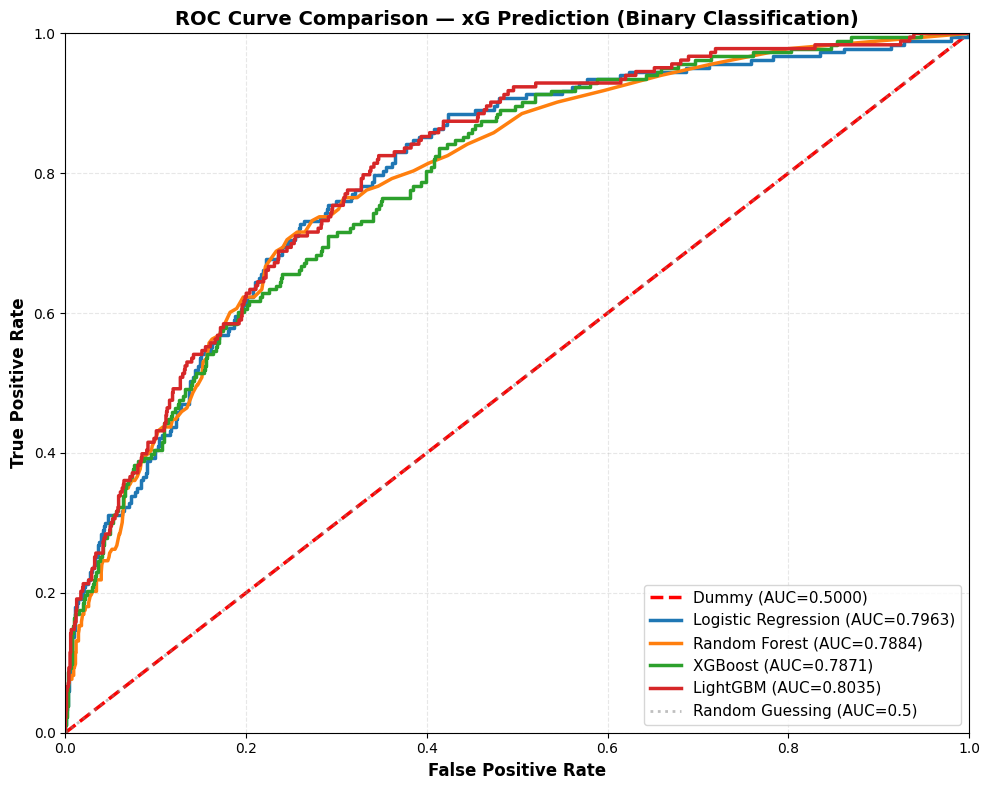

ROC curve saved as cycle2_roc_curve.png


In [21]:
fig, ax = plt.subplots(figsize=(10, 8))


fpr_dummy, tpr_dummy, _ = roc_curve(y_test, y_prob_dummy)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_prob_lgb)


ax.plot(fpr_dummy, tpr_dummy, color='red', linestyle='--', linewidth=2.5, 
        label=f'Dummy (AUC={auc_dummy:.4f})', zorder=1)
ax.plot(fpr_lr, tpr_lr, color='#1f77b4', linewidth=2.5, 
        label=f'Logistic Regression (AUC={auc_lr:.4f})', zorder=2)
ax.plot(fpr_rf, tpr_rf, color='#ff7f0e', linewidth=2.5, 
        label=f'Random Forest (AUC={auc_rf:.4f})', zorder=2)
ax.plot(fpr_xgb, tpr_xgb, color='#2ca02c', linewidth=2.5, 
        label=f'XGBoost (AUC={auc_xgb:.4f})', zorder=2)
ax.plot(fpr_lgb, tpr_lgb, color='#d62728', linewidth=2.5, 
        label=f'LightGBM (AUC={auc_lgb:.4f})', zorder=2)


ax.plot([0, 1], [0, 1], color='gray', linestyle=':', linewidth=2, alpha=0.5, label='Random Guessing (AUC=0.5)')

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve Comparison — xG Prediction (Binary Classification)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('../../docs/cycle2_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print('ROC curve saved as cycle2_roc_curve.png')

### Key Conclusions:
- **LightGBM leads** with AUC 0.8035.
- All three real models cluster tightly (AUC 0.787-0.796) — tuning will determine the winner
- Accuracy is NOT a useful metric here — models with lower accuracy can have higher AUC